In [1]:
%pip install arch --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Volatility & GARCH
import yfinance as yf
from arch import arch_model
from hmmlearn import hmm

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import xgboost as xgb

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ All imports successful")

✓ All imports successful


# Volatility Regime Detection
## GARCH-Based Labeling, Feature Engineering & Multi-Model Training with Backtesting

This notebook implements a complete pipeline for detecting financial market volatility regimes using:
- **3 Labeling Methods**: Rolling Realized Volatility, VIX Threshold, GARCH(1,1)
- **Feature Engineering**: 4 groups including OHLC-based volatility estimators
- **4 ML Models**: Logistic Regression, Random Forest, XGBoost, Markov-Switching HMM
- **Backtesting & MLflow**: Risk-adjusted strategy evaluation and experiment tracking

## Section 1: Data Loading and Exploration

Download SPY and VIX daily data from 2010–2024, compute log returns, and visualize price dynamics.

In [3]:
print("Downloading SPY and VIX data...")
spy = yf.download("SPY", start="2010-01-01", end="2024-12-31", progress=False)
vix = yf.download("^VIX", start="2010-01-01", end="2024-12-31", progress=False)

def fix_yf_columns(df):
    # If columns are MultiIndex, keep the price field level
    if isinstance(df.columns, pd.MultiIndex):
        # Usually columns look like ('Close', 'SPY') or ('SPY', 'Close')
        if "Close" in df.columns.get_level_values(0):
            df.columns = df.columns.get_level_values(0)
        elif "Close" in df.columns.get_level_values(1):
            df.columns = df.columns.get_level_values(1)
        else:
            df.columns = ["_".join(map(str, col)) for col in df.columns]
    return df

spy = fix_yf_columns(spy)
vix = fix_yf_columns(vix)

print("SPY columns:", spy.columns)
print("VIX columns:", vix.columns)

# Use Close if available, otherwise Adj Close
spy_price_col = "Close" if "Close" in spy.columns else "Adj Close"
vix_price_col = "Close" if "Close" in vix.columns else "Adj Close"

spy["LogReturn"] = np.log(spy[spy_price_col] / spy[spy_price_col].shift(1))

df = pd.DataFrame({
    "SPY_Close": spy[spy_price_col],
    "SPY_High": spy["High"],
    "SPY_Low": spy["Low"],
    "SPY_Open": spy["Open"],
    "SPY_LogReturn": spy["LogReturn"],
    "VIX": vix[vix_price_col]
}).dropna()

print("\n" + "="*70)
print("DATA OVERVIEW")
print("="*70)
print(f"Shape: {df.shape}")
print("\nSPY Data (first 5 rows):")
print(df.head())
print("\nBasic Statistics - SPY Close:")
print(df["SPY_Close"].describe())
print("\nBasic Statistics - VIX:")
print(df["VIX"].describe())
print("\nLog Returns Statistics:")
print(df["SPY_LogReturn"].describe())

SPY columns: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
VIX columns: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

DATA OVERVIEW
Shape: (3772, 6)

SPY Data (first 5 rows):
            SPY_Close   SPY_High    SPY_Low   SPY_Open  SPY_LogReturn  \
Date                                                                    
2010-01-05  85.020866  85.058280  84.437251  84.744027       0.002644   
2010-01-06  85.080719  85.290221  84.871217  84.938554       0.000704   
2010-01-07  85.439835  85.544586  84.684126  84.923557       0.004212   
2010-01-08  85.724174  85.761588  85.043292  85.215381       0.003322   
2010-01-11  85.843895  86.143181  85.477260  86.105773       0.001396   

                  VIX  
Date                   
2010-01-05  19.350000  
2010-01-06  19.160000  
2010-01-07  19.059999  
2010-01-08  18.129999  
2010-01-11  17.549999  

Basic Statistics - SPY Close:
count    3772.000000
mean      245.096055
std

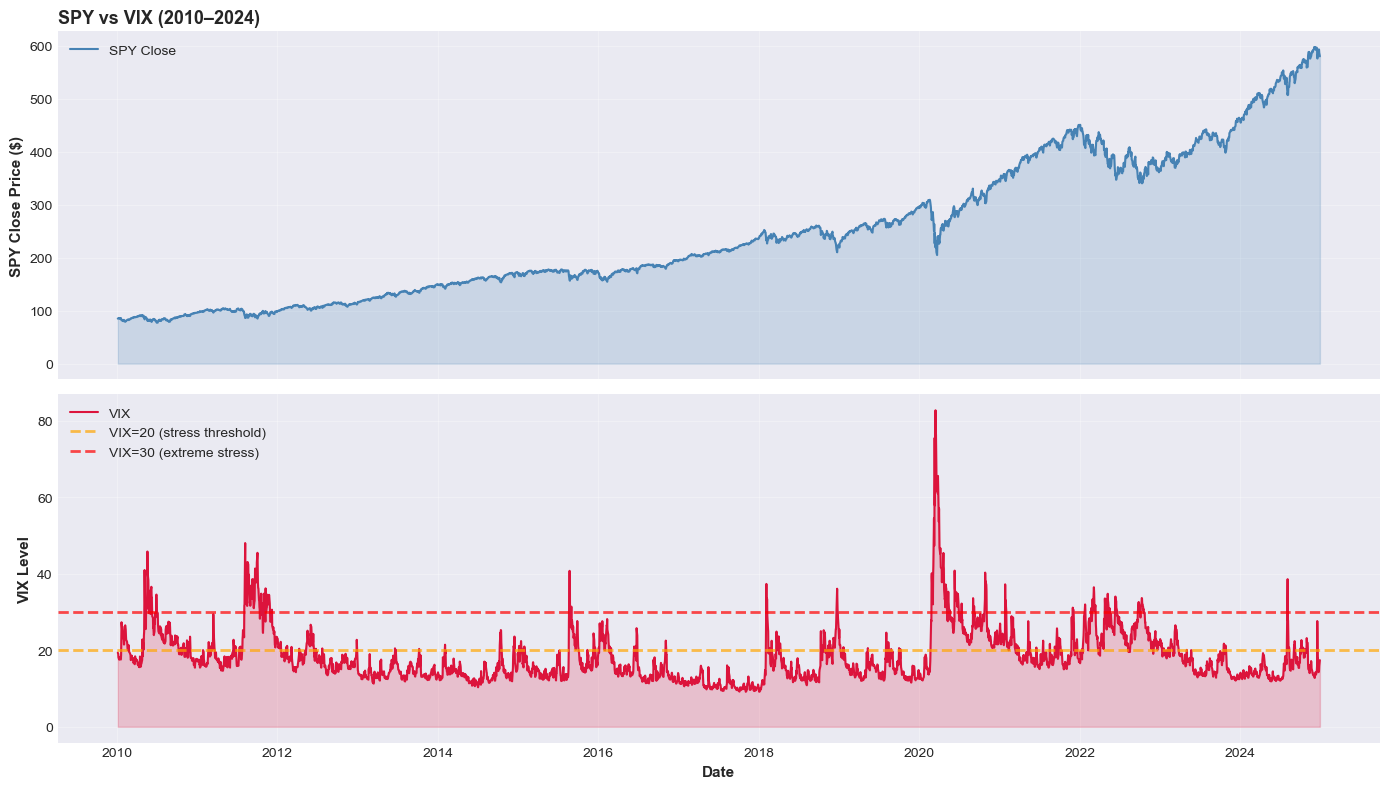

✓ SPY vs VIX plot generated


In [4]:
# Plot SPY Price and VIX (2010-2024)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# SPY Price
axes[0].plot(df.index, df['SPY_Close'], linewidth=1.5, color='steelblue', label='SPY Close')
axes[0].fill_between(df.index, df['SPY_Close'], alpha=0.2, color='steelblue')
axes[0].set_ylabel('SPY Close Price ($)', fontsize=11, fontweight='bold')
axes[0].set_title('SPY vs VIX (2010–2024)', fontsize=13, fontweight='bold', loc='left')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left', fontsize=10)

# VIX Index
axes[1].plot(df.index, df['VIX'], linewidth=1.5, color='crimson', label='VIX')
axes[1].fill_between(df.index, df['VIX'], alpha=0.2, color='crimson')
axes[1].axhline(y=20, color='orange', linestyle='--', linewidth=2, label='VIX=20 (stress threshold)', alpha=0.7)
axes[1].axhline(y=30, color='red', linestyle='--', linewidth=2, label='VIX=30 (extreme stress)', alpha=0.7)
axes[1].set_ylabel('VIX Level', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()
print("✓ SPY vs VIX plot generated")

## Section 2: Ground Truth Labeling — Method A: Rolling Realized Volatility

In [5]:
# Method A: Rolling Realized Volatility Threshold
print("\n" + "="*70)
print("METHOD A: ROLLING REALIZED VOLATILITY THRESHOLD")
print("="*70)

# Compute 20-day rolling standard deviation (Realized Volatility)
df['Realized_Vol'] = df['SPY_LogReturn'].rolling(window=20).std()

# Compute 252-day rolling median of Realized Vol
realized_vol_median = df['Realized_Vol'].rolling(window=252).median()

# Label: HighVol if Realized_Vol > rolling median, else LowVol
df['Label_A'] = (df['Realized_Vol'] > realized_vol_median).astype(int)
df['Label_A'] = df['Label_A'].map({1: 'HighVol', 0: 'LowVol'})

# Print class distribution
print("\nClass Distribution (Method A):")
print(df['Label_A'].value_counts())
print(f"\nPercentage Distribution:")
print(df['Label_A'].value_counts(normalize=True) * 100)


METHOD A: ROLLING REALIZED VOLATILITY THRESHOLD

Class Distribution (Method A):
Label_A
LowVol     2160
HighVol    1612
Name: count, dtype: int64

Percentage Distribution:
Label_A
LowVol     57.264051
HighVol    42.735949
Name: proportion, dtype: float64


## Section 3: Ground Truth Labeling — Method B: VIX Threshold

In [6]:
# Method B: VIX Threshold
print("\n" + "="*70)
print("METHOD B: VIX THRESHOLD (20)")
print("="*70)

# Label: HighVol if VIX > 20 (market stress threshold), else LowVol
df['Label_B'] = (df['VIX'] > 20).astype(int)
df['Label_B'] = df['Label_B'].map({1: 'HighVol', 0: 'LowVol'})

# Print class distribution
print("\nClass Distribution (Method B):")
print(df['Label_B'].value_counts())
print(f"\nPercentage Distribution:")
print(df['Label_B'].value_counts(normalize=True) * 100)

# Print dates when VIX exceeded 30 (extreme stress)
extreme_stress = df[df['VIX'] > 30]
print(f"\n\nDates when VIX exceeded 30 (Extreme Stress Periods):")
print(f"Number of days: {len(extreme_stress)}")
print(f"\nStress periods:")
for idx, row in extreme_stress.iterrows():
    print(f"  {idx.date()}: VIX = {row['VIX']:.2f}")

# Verify key periods
march_2020 = df.loc['2020-03']
print(f"\nMarch 2020 VIX stats - Min: {march_2020['VIX'].min():.2f}, Max: {march_2020['VIX'].max():.2f}, Mean: {march_2020['VIX'].mean():.2f}")

late_2022 = df.loc['2022-09':'2022-10']
print(f"Late 2022 VIX stats - Min: {late_2022['VIX'].min():.2f}, Max: {late_2022['VIX'].max():.2f}, Mean: {late_2022['VIX'].mean():.2f}")


METHOD B: VIX THRESHOLD (20)

Class Distribution (Method B):
Label_B
LowVol     2661
HighVol    1111
Name: count, dtype: int64

Percentage Distribution:
Label_B
LowVol     70.546129
HighVol    29.453871
Name: proportion, dtype: float64


Dates when VIX exceeded 30 (Extreme Stress Periods):
Number of days: 242

Stress periods:
  2010-05-06: VIX = 32.80
  2010-05-07: VIX = 40.95
  2010-05-14: VIX = 31.24
  2010-05-17: VIX = 30.84
  2010-05-18: VIX = 33.55
  2010-05-19: VIX = 35.32
  2010-05-20: VIX = 45.79
  2010-05-21: VIX = 40.10
  2010-05-24: VIX = 38.32
  2010-05-25: VIX = 34.61
  2010-05-26: VIX = 35.02
  2010-05-28: VIX = 32.07
  2010-06-01: VIX = 35.54
  2010-06-02: VIX = 30.17
  2010-06-04: VIX = 35.48
  2010-06-07: VIX = 36.57
  2010-06-08: VIX = 33.70
  2010-06-09: VIX = 33.73
  2010-06-10: VIX = 30.57
  2010-06-29: VIX = 34.13
  2010-06-30: VIX = 34.54
  2010-07-01: VIX = 32.86
  2010-07-02: VIX = 30.12
  2011-08-04: VIX = 31.66
  2011-08-05: VIX = 32.00
  2011-08-08: VIX = 4

## Section 4: Ground Truth Labeling — Method C: GARCH(1,1) Conditional Volatility

In [7]:
# Method C: GARCH(1,1) Conditional Volatility
print("\n" + "="*70)
print("METHOD C: GARCH(1,1) CONDITIONAL VOLATILITY")
print("="*70)

# Fit GARCH(1,1) on SPY log returns (scaled to percentage for numerical stability)
returns_scaled = df['SPY_LogReturn'].dropna() * 100
garch_model = arch_model(returns_scaled, vol='Garch', p=1, q=1)
garch_fitted = garch_model.fit(disp='off')

# Extract conditional volatility (sigma) from the model
df['GARCH_Vol'] = np.nan
df.loc[returns_scaled.index, 'GARCH_Vol'] = garch_fitted.conditional_volatility.values / 100

# Label: HighVol if GARCH conditional vol > median, else LowVol
garch_median = df['GARCH_Vol'].median()
df['Label_C'] = (df['GARCH_Vol'] > garch_median).astype(int)
df['Label_C'] = df['Label_C'].map({1: 'HighVol', 0: 'LowVol'})

# Print GARCH model summary
print("\nGARCH(1,1) Model Summary:")
print(garch_fitted.summary())

# Print class distribution
print("\nClass Distribution (Method C):")
print(df['Label_C'].value_counts())
print(f"\nPercentage Distribution:")
print(df['Label_C'].value_counts(normalize=True) * 100)


METHOD C: GARCH(1,1) CONDITIONAL VOLATILITY

GARCH(1,1) Model Summary:
                     Constant Mean - GARCH Model Results                      
Dep. Variable:          SPY_LogReturn   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4821.04
Distribution:                  Normal   AIC:                           9650.08
Method:            Maximum Likelihood   BIC:                           9675.02
                                        No. Observations:                 3772
Date:                Mon, Apr 27 2026   Df Residuals:                     3771
Time:                        23:52:29   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
-------------------------------------------------------------------

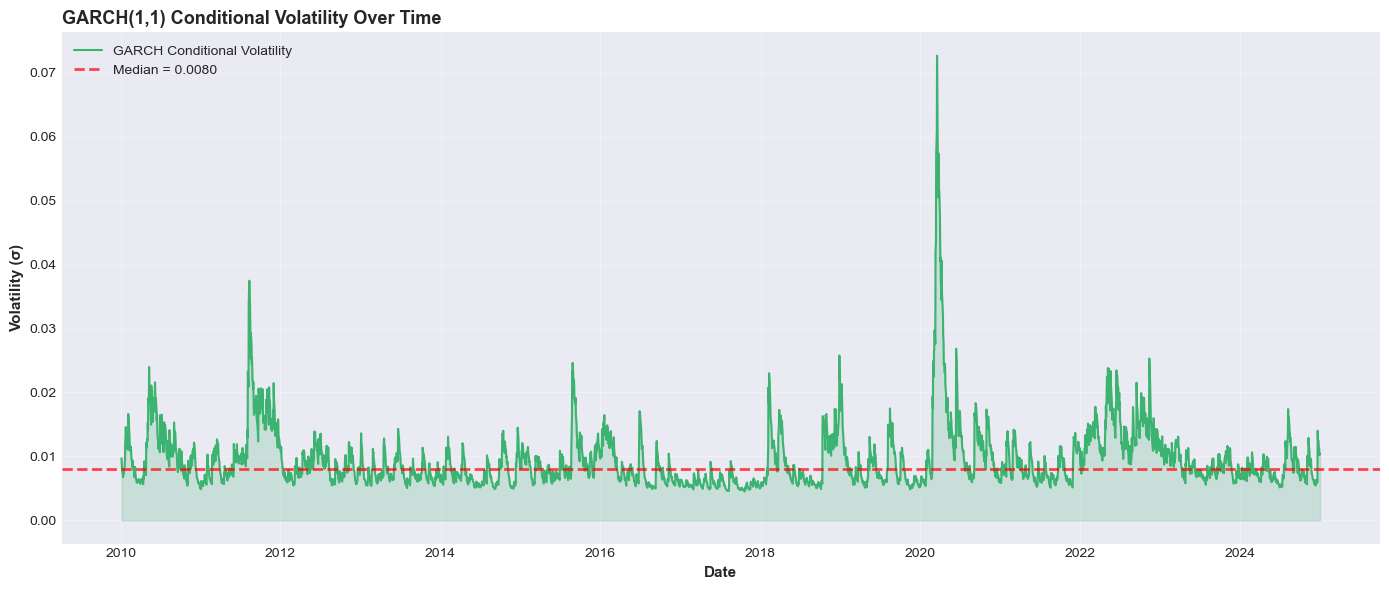

✓ GARCH volatility plot generated


In [8]:
# Plot GARCH Conditional Volatility
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['GARCH_Vol'], linewidth=1.5, color='mediumseagreen', label='GARCH Conditional Volatility')
ax.fill_between(df.index, df['GARCH_Vol'], alpha=0.2, color='mediumseagreen')
ax.axhline(y=garch_median, color='red', linestyle='--', linewidth=2, label=f'Median = {garch_median:.4f}', alpha=0.7)
ax.set_ylabel('Volatility (σ)', fontsize=11, fontweight='bold')
ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.set_title('GARCH(1,1) Conditional Volatility Over Time', fontsize=13, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()
print("✓ GARCH volatility plot generated")

## Section 5: Majority Vote and Final Label Visualization

In [9]:
# Majority Vote Across All 3 Methods
print("\n" + "="*70)
print("MAJORITY VOTE FOR FINAL LABEL")
print("="*70)

# Convert labels to numeric for voting
label_a_num = (df['Label_A'] == 'HighVol').astype(int)
label_b_num = (df['Label_B'] == 'HighVol').astype(int)
label_c_num = (df['Label_C'] == 'HighVol').astype(int)

# Majority vote: sum votes and threshold at > 1.5
df['Vote_Sum'] = label_a_num + label_b_num + label_c_num
df['Final_Label'] = df['Vote_Sum'].apply(lambda x: 'HighVol' if x >= 2 else 'LowVol')

print("\nClass Distribution (Final Label - Majority Vote):")
print(df['Final_Label'].value_counts())
print(f"\nPercentage Distribution:")
print(df['Final_Label'].value_counts(normalize=True) * 100)

# Verify key stress periods
try:
    march_2020_mode = df.loc['2020-03', 'Final_Label'].mode()[0]
    print(f"\nMarch 2020 regime: {march_2020_mode}")
except:
    march_2020_mode = df.loc['2020-03', 'Final_Label'].value_counts().idxmax()
    print(f"\nMarch 2020 regime: {march_2020_mode}")

try:
    late_2022_mode = df.loc['2022-09':'2022-10', 'Final_Label'].mode()[0]
    print(f"Late 2022 regime: {late_2022_mode}")
except:
    late_2022_mode = df.loc['2022-09':'2022-10', 'Final_Label'].value_counts().idxmax()
    print(f"Late 2022 regime: {late_2022_mode}")


MAJORITY VOTE FOR FINAL LABEL

Class Distribution (Final Label - Majority Vote):
Final_Label
LowVol     2176
HighVol    1596
Name: count, dtype: int64

Percentage Distribution:
Final_Label
LowVol     57.688229
HighVol    42.311771
Name: proportion, dtype: float64

March 2020 regime: HighVol
Late 2022 regime: HighVol


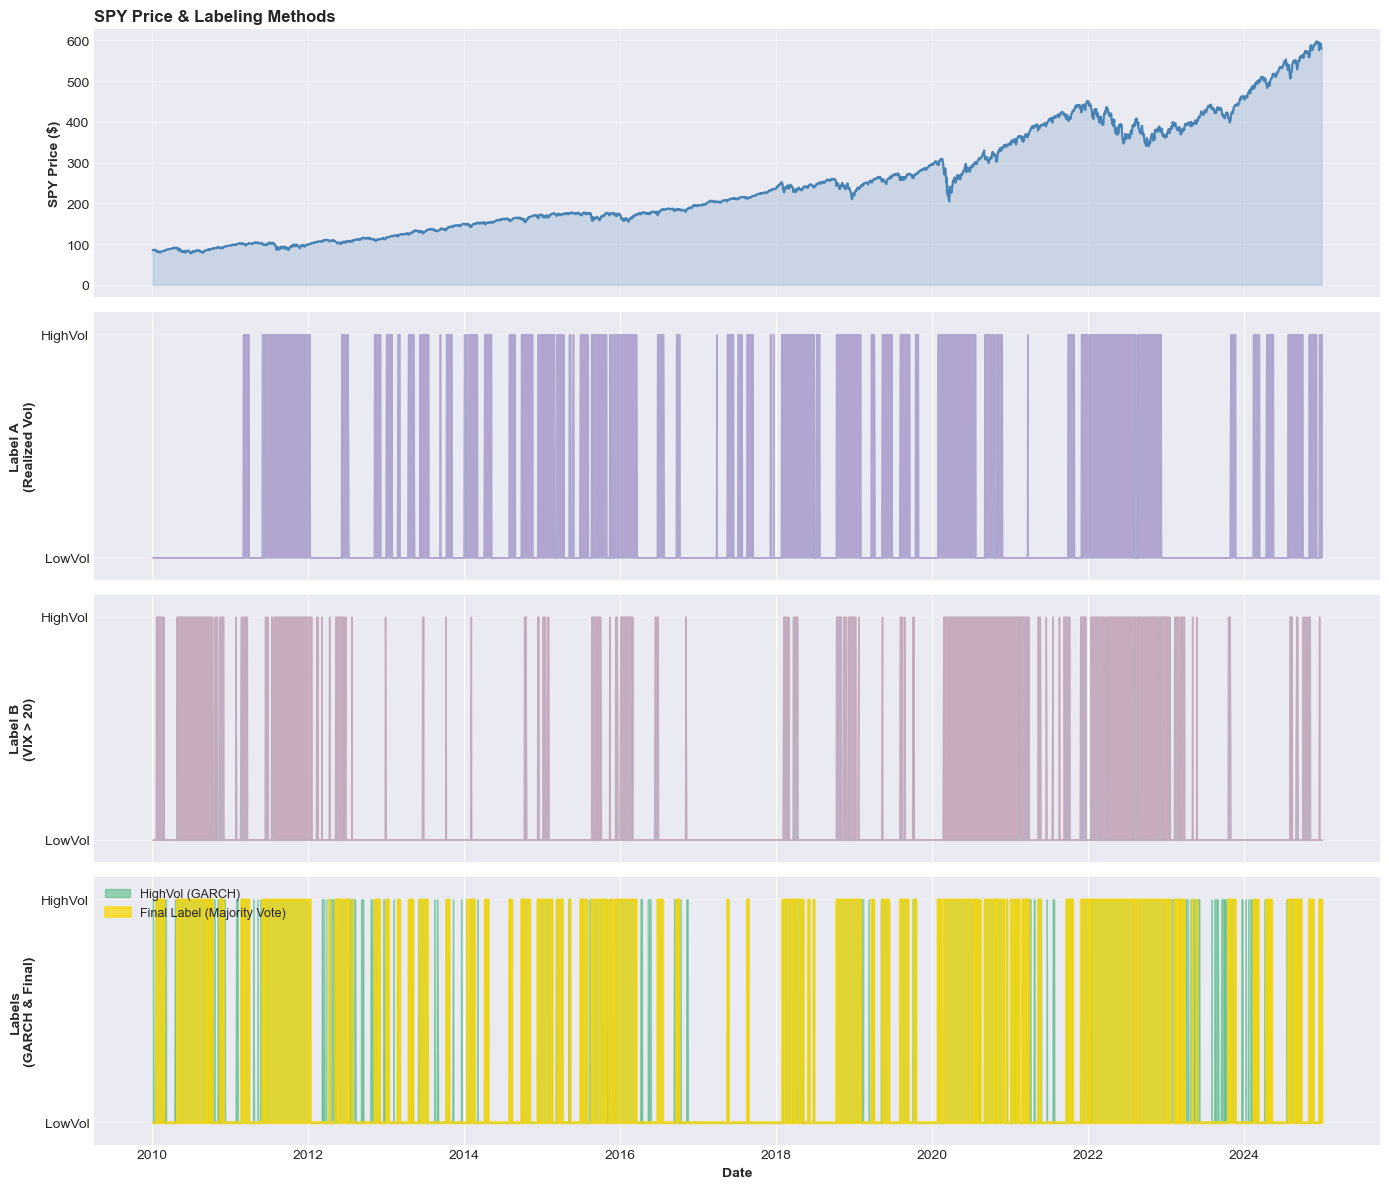

✓ 4-panel labeling comparison plot generated


In [10]:
# Plot All 3 Label Series + SPY Price (4-Panel Figure)
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Convert labels to numeric for plotting
label_a_plot = (df['Label_A'] == 'HighVol').astype(int)
label_b_plot = (df['Label_B'] == 'HighVol').astype(int)
label_c_plot = (df['Label_C'] == 'HighVol').astype(int)
final_label_plot = (df['Final_Label'] == 'HighVol').astype(int)

# Panel 1: SPY Price
axes[0].plot(df.index, df['SPY_Close'], linewidth=1.5, color='steelblue')
axes[0].fill_between(df.index, df['SPY_Close'], alpha=0.2, color='steelblue')
axes[0].set_ylabel('SPY Price ($)', fontsize=10, fontweight='bold')
axes[0].set_title('SPY Price & Labeling Methods', fontsize=12, fontweight='bold', loc='left')
axes[0].grid(True, alpha=0.3)

# Panel 2: Label A (Realized Vol)
axes[1].fill_between(df.index, label_a_plot, alpha=0.5, color='purple', label='HighVol')
axes[1].fill_between(df.index, label_a_plot, 0, alpha=0.5, color='lightblue', label='LowVol')
axes[1].set_ylabel('Label A\n(Realized Vol)', fontsize=10, fontweight='bold')
axes[1].set_ylim(-0.1, 1.1)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['LowVol', 'HighVol'])
axes[1].grid(True, alpha=0.3, axis='y')

# Panel 3: Label B (VIX)
axes[2].fill_between(df.index, label_b_plot, alpha=0.5, color='crimson', label='HighVol')
axes[2].fill_between(df.index, label_b_plot, 0, alpha=0.5, color='lightblue', label='LowVol')
axes[2].set_ylabel('Label B\n(VIX > 20)', fontsize=10, fontweight='bold')
axes[2].set_ylim(-0.1, 1.1)
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['LowVol', 'HighVol'])
axes[2].grid(True, alpha=0.3, axis='y')

# Panel 4: Label C (GARCH) & Final
axes[3].fill_between(df.index, label_c_plot, alpha=0.5, color='mediumseagreen', label='HighVol (GARCH)')
axes[3].fill_between(df.index, final_label_plot, alpha=0.7, step='mid', color='gold', label='Final Label (Majority Vote)', linewidth=2)
axes[3].set_ylabel('Labels\n(GARCH & Final)', fontsize=10, fontweight='bold')
axes[3].set_xlabel('Date', fontsize=10, fontweight='bold')
axes[3].set_ylim(-0.1, 1.1)
axes[3].set_yticks([0, 1])
axes[3].set_yticklabels(['LowVol', 'HighVol'])
axes[3].grid(True, alpha=0.3, axis='y')
axes[3].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()
print("✓ 4-panel labeling comparison plot generated")

## Section 6: Feature Engineering — Group 1: Realized Volatility Features

In [11]:
# Feature Engineering: Group 1 — Realized Volatility Features
print("\n" + "="*70)
print("FEATURE ENGINEERING - GROUP 1: REALIZED VOLATILITY")
print("="*70)

# Rolling standard deviation of log returns
df['Vol_5D'] = df['SPY_LogReturn'].rolling(window=5).std()
df['Vol_10D'] = df['SPY_LogReturn'].rolling(window=10).std()
df['Vol_20D'] = df['SPY_LogReturn'].rolling(window=20).std()

# Vol ratio: short-term vs long-term
df['Vol_Ratio_5_20'] = df['Vol_5D'] / df['Vol_20D']

# Parkinson Volatility Estimator: sqrt(1/(4*ln(2)) * (ln(H/L))^2)
df['Log_HL'] = np.log(df['SPY_High'] / df['SPY_Low'])
df['Parkinson_Vol'] = np.sqrt((1 / (4 * np.log(2))) * (df['Log_HL'] ** 2))

# Garman-Klass Volatility: 0.5*(ln(H/L))^2 - (2*ln(2)-1)*(ln(C/O))^2
df['Log_CO'] = np.log(df['SPY_Close'] / df['SPY_Open'])
df['Garman_Klass_Vol'] = np.sqrt(
    0.5 * (df['Log_HL'] ** 2) - (2 * np.log(2) - 1) * (df['Log_CO'] ** 2)
)

print("✓ Realized volatility features computed")


FEATURE ENGINEERING - GROUP 1: REALIZED VOLATILITY
✓ Realized volatility features computed


In [12]:
# Feature Engineering: Group 2 — VIX-Based Features
print("\n" + "="*70)
print("FEATURE ENGINEERING - GROUP 2: VIX-BASED FEATURES")
print("="*70)

# VIX level (raw)
df['VIX_Level'] = df['VIX']

# 5-day change in VIX
df['VIX_Change_5D'] = df['VIX'].pct_change(5)

# VIX / 20-day realized vol ratio (Implied vs Realized spread)
df['VIX_RealVol_Ratio'] = df['VIX'] / (df['Vol_20D'] * 100)

print("✓ VIX-based features computed")


FEATURE ENGINEERING - GROUP 2: VIX-BASED FEATURES
✓ VIX-based features computed


In [13]:
# Feature Engineering: Group 3 — Return Features
print("\n" + "="*70)
print("FEATURE ENGINEERING - GROUP 3: RETURN FEATURES")
print("="*70)

# Log returns at different windows
df['Return_1D'] = df['SPY_LogReturn']
df['Return_5D'] = df['SPY_LogReturn'].rolling(window=5).sum()
df['Return_20D'] = df['SPY_LogReturn'].rolling(window=20).sum()

# Rolling skewness and kurtosis of returns
df['Skewness_20D'] = df['SPY_LogReturn'].rolling(window=20).skew()
df['Kurtosis_20D'] = df['SPY_LogReturn'].rolling(window=20).kurt()

print("✓ Return features computed")


FEATURE ENGINEERING - GROUP 3: RETURN FEATURES
✓ Return features computed


In [14]:
# Feature Engineering: Group 4 — Range & Momentum Features
print("\n" + "="*70)
print("FEATURE ENGINEERING - GROUP 4: RANGE & MOMENTUM FEATURES")
print("="*70)

# ATR (14-day): Average True Range
df['TR'] = np.maximum(
    df['SPY_High'] - df['SPY_Low'],
    np.maximum(
        np.abs(df['SPY_High'] - df['SPY_Close'].shift(1)),
        np.abs(df['SPY_Low'] - df['SPY_Close'].shift(1))
    )
)
df['ATR_14D'] = df['TR'].rolling(window=14).mean()

# High-Low normalized range
df['HL_Range'] = (df['SPY_High'] - df['SPY_Low']) / df['SPY_Close']

# RSI (14-day): Relative Strength Index
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI_14D'] = compute_rsi(df['SPY_Close'], window=14)

# Bollinger Band width (20-day)
bb_mid = df['SPY_Close'].rolling(window=20).mean()
bb_std = df['SPY_Close'].rolling(window=20).std()
df['BB_Width'] = (2 * bb_std) / bb_mid

print("✓ Range & momentum features computed")


FEATURE ENGINEERING - GROUP 4: RANGE & MOMENTUM FEATURES
✓ Range & momentum features computed


## Section 7: Feature Cleanup and Separation Analysis

In [15]:
# Drop NaN rows
print("\n" + "="*70)
print("FEATURE CLEANUP")
print("="*70)

print(f"Rows before cleanup: {len(df)}")
df_features = df.dropna()
print(f"Rows after removing NaN: {len(df_features)}")

# Define feature list (excluding labels and auxiliary columns)
feature_cols = [
    'Vol_5D', 'Vol_10D', 'Vol_20D', 'Vol_Ratio_5_20',
    'Parkinson_Vol', 'Garman_Klass_Vol',
    'VIX_Level', 'VIX_Change_5D', 'VIX_RealVol_Ratio',
    'Return_1D', 'Return_5D', 'Return_20D',
    'Skewness_20D', 'Kurtosis_20D',
    'ATR_14D', 'HL_Range', 'RSI_14D', 'BB_Width'
]

print(f"\nTotal features: {len(feature_cols)}")
print(f"Final dataset shape: {df_features[feature_cols].shape}")
print(f"\nFeature list:")
for i, feat in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {feat}")


FEATURE CLEANUP
Rows before cleanup: 3772
Rows after removing NaN: 3753

Total features: 18
Final dataset shape: (3753, 18)

Feature list:
   1. Vol_5D
   2. Vol_10D
   3. Vol_20D
   4. Vol_Ratio_5_20
   5. Parkinson_Vol
   6. Garman_Klass_Vol
   7. VIX_Level
   8. VIX_Change_5D
   9. VIX_RealVol_Ratio
  10. Return_1D
  11. Return_5D
  12. Return_20D
  13. Skewness_20D
  14. Kurtosis_20D
  15. ATR_14D
  16. HL_Range
  17. RSI_14D
  18. BB_Width



Plotting feature distributions by regime...


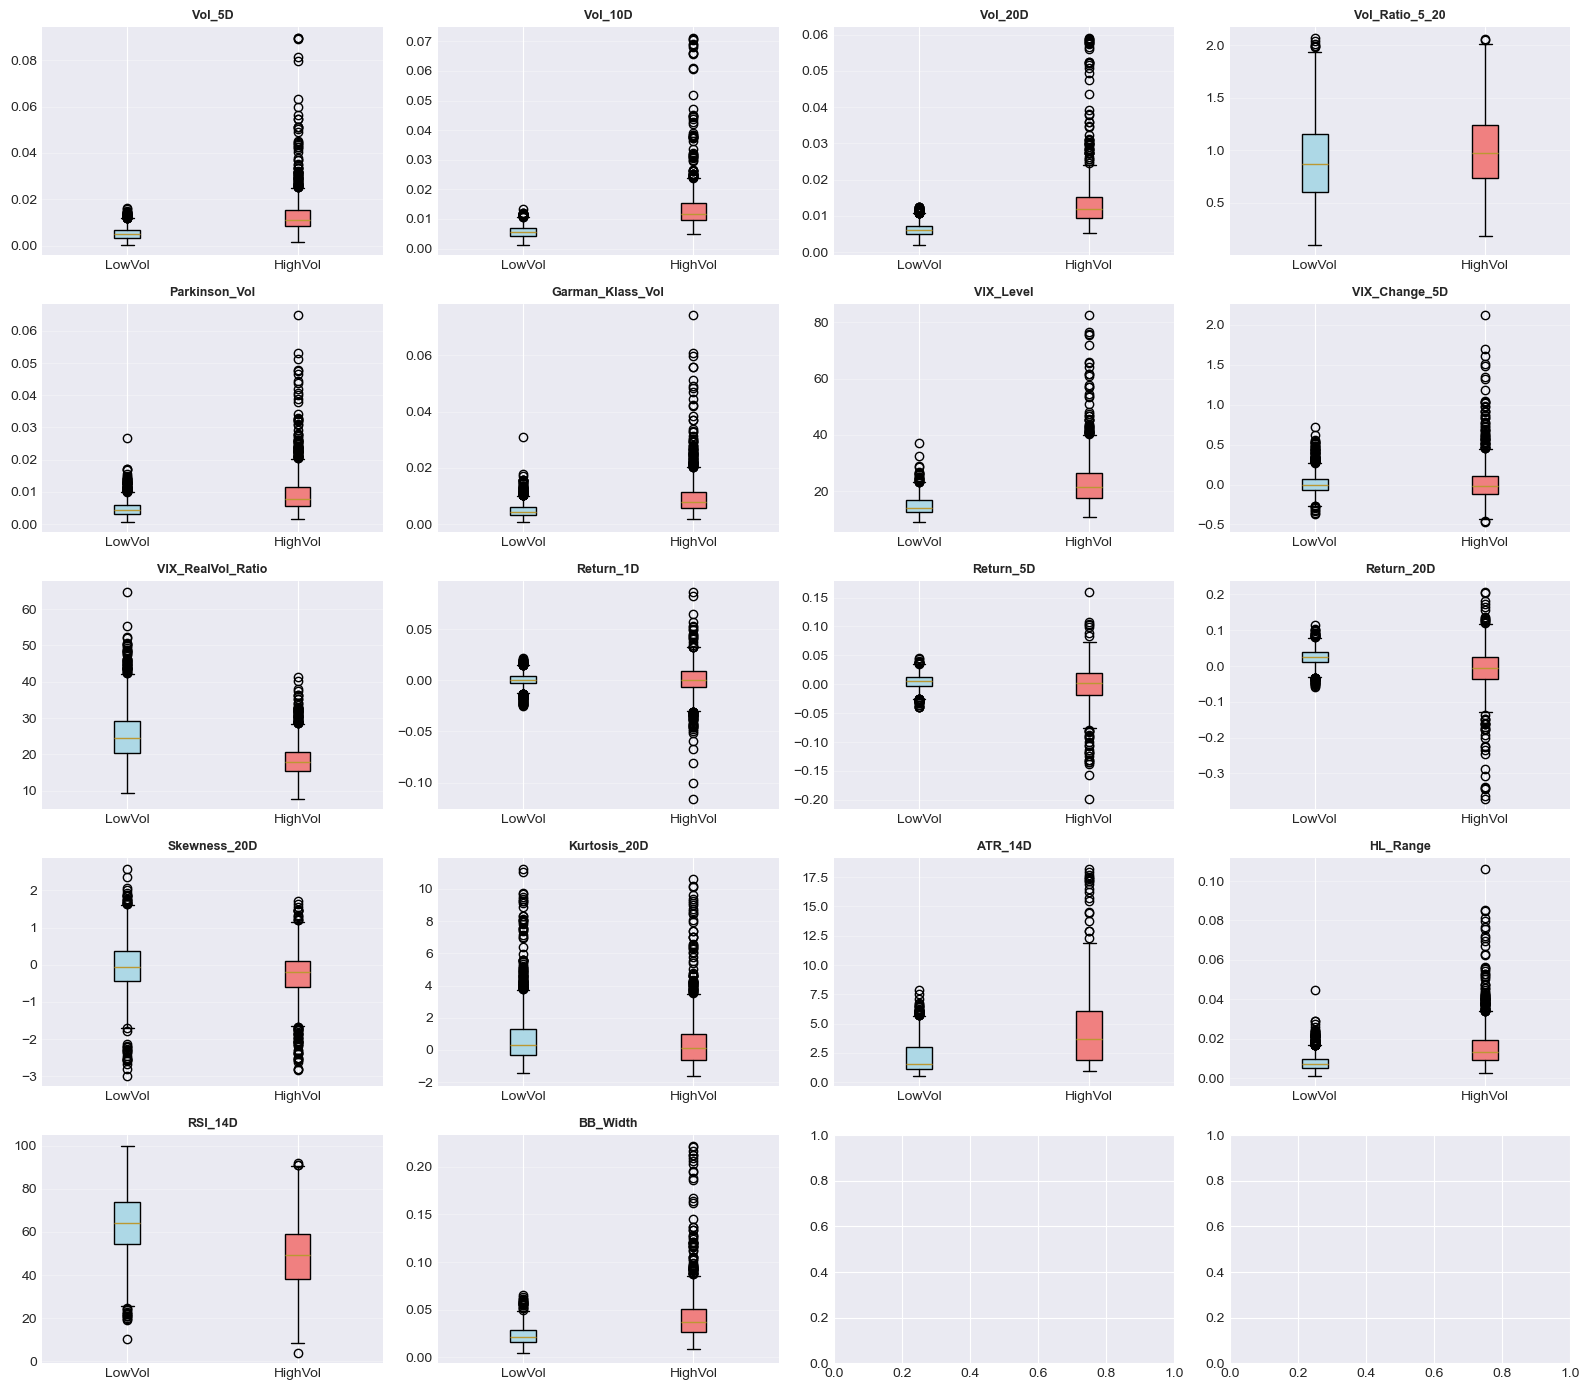

✓ Feature box plots generated


In [16]:
# Box plots for each feature grouped by Final_Label
print("\nPlotting feature distributions by regime...")
fig, axes = plt.subplots(5, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, feat in enumerate(feature_cols):
    ax = axes[idx]
    
    # Box plot
    data_to_plot = [
        df_features[df_features['Final_Label'] == 'LowVol'][feat].dropna(),
        df_features[df_features['Final_Label'] == 'HighVol'][feat].dropna()
    ]
    bp = ax.boxplot(data_to_plot, labels=['LowVol', 'HighVol'], patch_artist=True)
    
    # Color boxes
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("✓ Feature box plots generated")

In [17]:
# Feature Separation Power (Cohen's d-like metric)
print("\n" + "="*70)
print("FEATURE SEPARATION POWER (Cohen's d)")
print("="*70)

separation_scores = []

for feat in feature_cols:
    low_vol = df_features[df_features['Final_Label'] == 'LowVol'][feat].dropna()
    high_vol = df_features[df_features['Final_Label'] == 'HighVol'][feat].dropna()
    
    mean_diff = abs(high_vol.mean() - low_vol.mean())
    pooled_std = np.sqrt((low_vol.std() ** 2 + high_vol.std() ** 2) / 2)
    
    # Cohen's d
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    
    separation_scores.append({
        'Feature': feat,
        'LowVol_Mean': low_vol.mean(),
        'HighVol_Mean': high_vol.mean(),
        'Cohen_d': cohens_d
    })

sep_df = pd.DataFrame(separation_scores).sort_values('Cohen_d', ascending=False)

print("\nTop 10 Features by Separation Power:")
print(sep_df.head(10).to_string(index=False))


FEATURE SEPARATION POWER (Cohen's d)

Top 10 Features by Separation Power:
          Feature  LowVol_Mean  HighVol_Mean  Cohen_d
          Vol_10D     0.005688      0.013454 1.499700
          Vol_20D     0.006180      0.013319 1.473334
        VIX_Level    14.885788     23.106574 1.364794
           Vol_5D     0.005399      0.013061 1.291555
VIX_RealVol_Ratio    25.529261     18.411993 1.204640
         BB_Width     0.023219      0.042294 1.019308
         HL_Range     0.007931      0.015718 1.001618
    Parkinson_Vol     0.004765      0.009440 1.000966
          RSI_14D    63.561200     48.995121 0.991390
          ATR_14D     2.119869      4.320425 0.984249


## Section 8: Model Training - Data Preparation

In [18]:
# Data Preparation for Model Training
print("\n" + "="*70)
print("MODEL TRAINING - DATA PREPARATION")
print("="*70)

# Map labels to binary: HighVol=1, LowVol=0
df_features['Label'] = (df_features['Final_Label'] == 'HighVol').astype(int)

# Prepare feature matrix and target
X = df_features[feature_cols].copy()
y = df_features['Label'].copy()

# Time-based split: Train 2010-2020, Val 2021-2022, Test 2023-2024
train_end = pd.Timestamp('2020-12-31')
val_end = pd.Timestamp('2022-12-31')

train_mask = df_features.index <= train_end
val_mask = (df_features.index > train_end) & (df_features.index <= val_end)
test_mask = df_features.index > val_end

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain set: {X_train.shape[0]} samples ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Val set:   {X_val.shape[0]} samples ({X_val.index[0].date()} to {X_val.index[-1].date()})")
print(f"Test set:  {X_test.shape[0]} samples ({X_test.index[0].date()} to {X_test.index[-1].date()})")
print(f"\nClass distribution - Train: {y_train.value_counts().to_dict()}")
print(f"Class distribution - Val:   {y_val.value_counts().to_dict()}")
print(f"Class distribution - Test:  {y_test.value_counts().to_dict()}")


MODEL TRAINING - DATA PREPARATION

Train set: 2749 samples (2010-02-02 to 2020-12-31)
Val set:   503 samples (2021-01-04 to 2022-12-30)
Test set:  501 samples (2023-01-03 to 2024-12-30)

Class distribution - Train: {0: 1634, 1: 1115}
Class distribution - Val:   {1: 326, 0: 177}
Class distribution - Test:  {0: 354, 1: 147}


In [19]:
# Initialize results storage
model_results = {}

# Model 1: Logistic Regression (Baseline)
print("\n" + "="*70)
print("MODEL 1: LOGISTIC REGRESSION (BASELINE)")
print("="*70)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_val_pred_lr = lr.predict(X_val_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)
y_test_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Store results
model_results['Logistic Regression'] = {
    'model': lr,
    'y_test_pred': y_test_pred_lr,
    'y_test_proba': y_test_proba_lr,
    'type': 'sklearn'
}

print("\nValidation Set Results:")
print(classification_report(y_val, y_val_pred_lr, target_names=['LowVol', 'HighVol']))

print("\nTest Set Results:")
print(classification_report(y_test, y_test_pred_lr, target_names=['LowVol', 'HighVol']))

test_auc_lr = roc_auc_score(y_test, y_test_proba_lr)
print(f"Test AUC: {test_auc_lr:.4f}")


MODEL 1: LOGISTIC REGRESSION (BASELINE)

Validation Set Results:
              precision    recall  f1-score   support

      LowVol       0.96      0.77      0.85       177
     HighVol       0.89      0.98      0.93       326

    accuracy                           0.91       503
   macro avg       0.92      0.87      0.89       503
weighted avg       0.91      0.91      0.90       503


Test Set Results:
              precision    recall  f1-score   support

      LowVol       1.00      0.65      0.79       354
     HighVol       0.54      1.00      0.71       147

    accuracy                           0.75       501
   macro avg       0.77      0.83      0.75       501
weighted avg       0.87      0.75      0.76       501

Test AUC: 0.9257


In [20]:
# Model 2: Random Forest
print("\n" + "="*70)
print("MODEL 2: RANDOM FOREST")
print("="*70)

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_val_pred_rf = rf.predict(X_val_scaled)
y_test_pred_rf = rf.predict(X_test_scaled)
y_test_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Store results
model_results['Random Forest'] = {
    'model': rf,
    'y_test_pred': y_test_pred_rf,
    'y_test_proba': y_test_proba_rf,
    'type': 'sklearn'
}

print("\nValidation Set Results:")
print(classification_report(y_val, y_val_pred_rf, target_names=['LowVol', 'HighVol']))

print("\nTest Set Results:")
print(classification_report(y_test, y_test_pred_rf, target_names=['LowVol', 'HighVol']))

test_auc_rf = roc_auc_score(y_test, y_test_proba_rf)
print(f"Test AUC: {test_auc_rf:.4f}")

# Feature importance
print("\nTop 10 Feature Importances:")
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print(feat_imp.head(10).to_string(index=False))


MODEL 2: RANDOM FOREST

Validation Set Results:
              precision    recall  f1-score   support

      LowVol       0.95      0.85      0.90       177
     HighVol       0.92      0.98      0.95       326

    accuracy                           0.93       503
   macro avg       0.94      0.91      0.92       503
weighted avg       0.93      0.93      0.93       503


Test Set Results:
              precision    recall  f1-score   support

      LowVol       0.96      0.78      0.86       354
     HighVol       0.64      0.92      0.75       147

    accuracy                           0.82       501
   macro avg       0.80      0.85      0.81       501
weighted avg       0.86      0.82      0.83       501

Test AUC: 0.9180

Top 10 Feature Importances:
          Feature  Importance
          Vol_10D    0.265347
          Vol_20D    0.259264
           Vol_5D    0.123472
        VIX_Level    0.100063
          ATR_14D    0.056431
VIX_RealVol_Ratio    0.051773
         BB_Width    0

In [21]:
# Model 3: XGBoost
print("\n" + "="*70)
print("MODEL 3: XGBOOST")
print("="*70)

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_train)

y_val_pred_xgb = xgb_model.predict(X_val_scaled)
y_test_pred_xgb = xgb_model.predict(X_test_scaled)
y_test_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Store results
model_results['XGBoost'] = {
    'model': xgb_model,
    'y_test_pred': y_test_pred_xgb,
    'y_test_proba': y_test_proba_xgb,
    'type': 'xgboost'
}

print("\nValidation Set Results:")
print(classification_report(y_val, y_val_pred_xgb, target_names=['LowVol', 'HighVol']))

print("\nTest Set Results:")
print(classification_report(y_test, y_test_pred_xgb, target_names=['LowVol', 'HighVol']))

test_auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)
print(f"Test AUC: {test_auc_xgb:.4f}")

# Feature importance
print("\nTop 10 Feature Importances:")
feat_imp_xgb = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feat_imp_xgb.head(10).to_string(index=False))


MODEL 3: XGBOOST

Validation Set Results:
              precision    recall  f1-score   support

      LowVol       0.99      0.87      0.93       177
     HighVol       0.93      1.00      0.96       326

    accuracy                           0.95       503
   macro avg       0.96      0.93      0.95       503
weighted avg       0.95      0.95      0.95       503


Test Set Results:
              precision    recall  f1-score   support

      LowVol       0.97      0.79      0.87       354
     HighVol       0.65      0.95      0.77       147

    accuracy                           0.83       501
   macro avg       0.81      0.87      0.82       501
weighted avg       0.88      0.83      0.84       501

Test AUC: 0.9264

Top 10 Feature Importances:
          Feature  Importance
          Vol_10D    0.496440
          Vol_20D    0.138283
        VIX_Level    0.041770
          ATR_14D    0.037334
           Vol_5D    0.033356
         BB_Width    0.027360
     Skewness_20D    0.02517

In [22]:
# Model 4: Markov-Switching HMM on GARCH Residuals
print("\n" + "="*70)
print("MODEL 4: MARKOV-SWITCHING HMM (STATE-OF-THE-ART)")
print("="*70)

# Fit GARCH on training returns
train_returns = df_features.loc[train_mask, 'SPY_LogReturn'].dropna() * 100
garch_train = arch_model(train_returns, vol='Garch', p=1, q=1)
garch_fit_train = garch_train.fit(disp='off')

# Extract standardized residuals from full sample GARCH (use for HMM)
residuals_full = garch_fitted.std_resid.dropna()

# Fit 2-state Gaussian HMM on standardized residuals
print("\nFitting 2-state Gaussian HMM on GARCH standardized residuals...")
hmm_model = hmm.GaussianHMM(n_components=2, covariance_type='full', random_state=42)
residuals_for_hmm = residuals_full.values.reshape(-1, 1)
hmm_model.fit(residuals_for_hmm)

# Get HMM states and state probabilities
hidden_states = hmm_model.predict(residuals_for_hmm)
state_probs = hmm_model.predict_proba(residuals_for_hmm)

# Map HMM states to dataframe
df_hmm = pd.DataFrame({
    'HMM_State': hidden_states,
    'State0_Prob': state_probs[:, 0],
    'State1_Prob': state_probs[:, 1]
}, index=residuals_full.index)

# Determine which state has higher variance (HighVol)
state_vars = [residuals_full[hidden_states == i].var() for i in [0, 1]]
highvol_state = np.argmax(state_vars)

print(f"\nHMM State Statistics:")
print(f"State 0: Mean={hmm_model.means_[0][0]:.4f}, Var={state_vars[0]:.4f}")
print(f"State 1: Mean={hmm_model.means_[1][0]:.4f}, Var={state_vars[1]:.4f}")
print(f"High Volatility State: {highvol_state}")

# Align test set predictions
test_residuals = residuals_full.loc[residuals_full.index.intersection(df_features.index[test_mask])]
test_states = hmm_model.predict(test_residuals.values.reshape(-1, 1))
test_probs = hmm_model.predict_proba(test_residuals.values.reshape(-1, 1))

# Convert states: HighVol state = 1, LowVol state = 0
y_test_pred_hmm = (test_states == highvol_state).astype(int)
y_test_proba_hmm = test_probs[:, highvol_state]

# Store results
model_results['HMM'] = {
    'model': hmm_model,
    'y_test_pred': y_test_pred_hmm,
    'y_test_proba': y_test_proba_hmm,
    'type': 'hmm'
}

print("\nTest Set Results:")
print(classification_report(y_test, y_test_pred_hmm, target_names=['LowVol', 'HighVol']))

test_auc_hmm = roc_auc_score(y_test, y_test_proba_hmm)
print(f"Test AUC: {test_auc_hmm:.4f}")


MODEL 4: MARKOV-SWITCHING HMM (STATE-OF-THE-ART)

Fitting 2-state Gaussian HMM on GARCH standardized residuals...

HMM State Statistics:
State 0: Mean=-0.1466, Var=0.9974
State 1: Mean=0.3350, Var=nan
High Volatility State: 1

Test Set Results:
              precision    recall  f1-score   support

      LowVol       0.71      1.00      0.83       354
     HighVol       1.00      0.01      0.01       147

    accuracy                           0.71       501
   macro avg       0.85      0.50      0.42       501
weighted avg       0.79      0.71      0.59       501

Test AUC: 0.4739


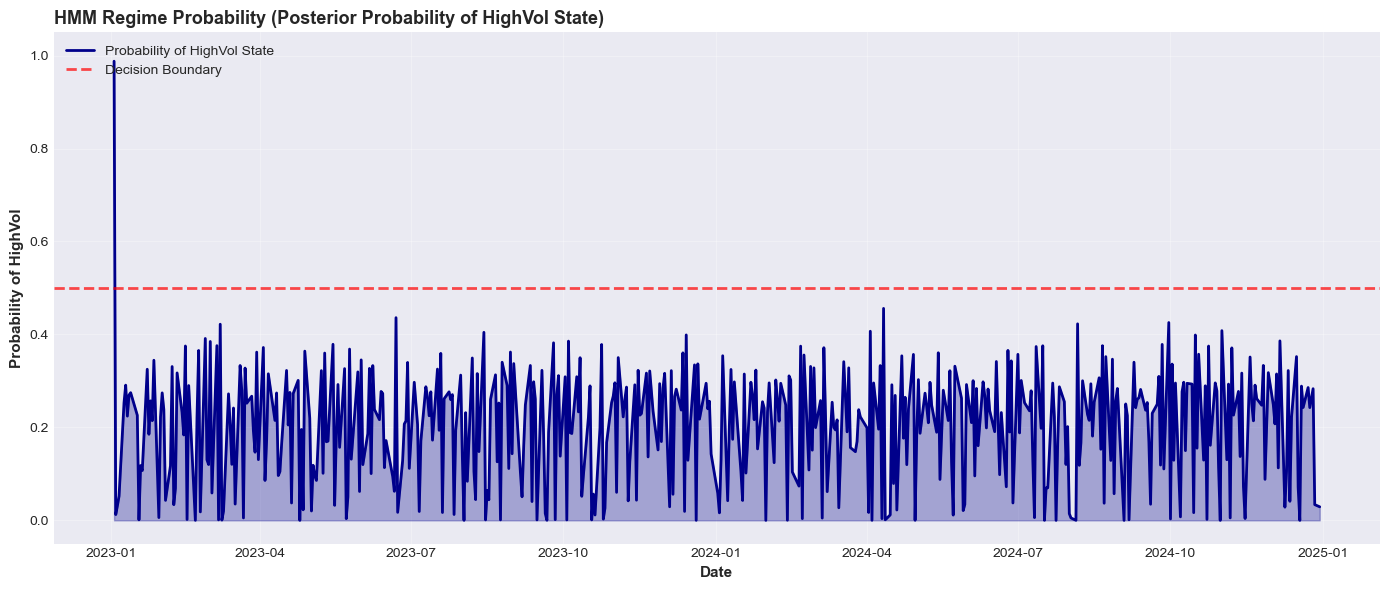

✓ HMM regime probability plot generated


In [23]:
# Plot HMM Regime Probabilities Over Time
fig, ax = plt.subplots(figsize=(14, 6))

test_dates = X_test.index
ax.plot(test_dates, y_test_proba_hmm, linewidth=2, color='darkblue', label='Probability of HighVol State')
ax.fill_between(test_dates, y_test_proba_hmm, alpha=0.3, color='darkblue')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Decision Boundary')
ax.set_ylabel('Probability of HighVol', fontsize=11, fontweight='bold')
ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.set_title('HMM Regime Probability (Posterior Probability of HighVol State)', fontsize=13, fontweight='bold', loc='left')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()
print("✓ HMM regime probability plot generated")

In [24]:
# Bonus: Isolation Forest (Unsupervised Anomaly Detection)
print("\n" + "="*70)
print("BONUS: ISOLATION FOREST (UNSUPERVISED ANOMALY DETECTION)")
print("="*70)
print("Note: This trains ONLY on LowVol days; anomalies are treated as HighVol")

# Train on LowVol days only
X_train_lowvol = X_train_scaled[y_train == 0]

iso_forest = IsolationForest(contamination=0.1, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_lowvol)

# Predict: -1 = anomaly (HighVol), 1 = normal (LowVol)
y_test_pred_iso = iso_forest.predict(X_test_scaled)
y_test_pred_iso = (y_test_pred_iso == -1).astype(int)  # Convert to 0/1 format

# Store results
model_results['Isolation Forest'] = {
    'model': iso_forest,
    'y_test_pred': y_test_pred_iso,
    'type': 'isolation_forest'
}

print("\nTest Set Results:")
print(classification_report(y_test, y_test_pred_iso, target_names=['LowVol', 'HighVol']))
print("(This is an unsupervised approach - consider as alternative signal)")


BONUS: ISOLATION FOREST (UNSUPERVISED ANOMALY DETECTION)
Note: This trains ONLY on LowVol days; anomalies are treated as HighVol

Test Set Results:
              precision    recall  f1-score   support

      LowVol       0.93      0.69      0.79       354
     HighVol       0.54      0.88      0.67       147

    accuracy                           0.74       501
   macro avg       0.74      0.78      0.73       501
weighted avg       0.82      0.74      0.76       501

(This is an unsupervised approach - consider as alternative signal)


In [25]:
# Model Comparison
print("\n" + "="*70)
print("MODEL COMPARISON - TEST SET RESULTS")
print("="*70)

comparison_data = []

for model_name, result in model_results.items():
    y_pred = result['y_test_pred']
    
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # AUC only for models that have probabilities
    if 'y_test_proba' in result:
        auc = roc_auc_score(y_test, result['y_test_proba'])
    else:
        auc = np.nan
    
    comparison_data.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc
    })

comp_df = pd.DataFrame(comparison_data)
print("\n" + comp_df.to_string(index=False))

# Identify best models
print(f"\n{'Best Accuracy:':<20} {comp_df.loc[comp_df['Accuracy'].idxmax(), 'Model']} ({comp_df['Accuracy'].max():.4f})")
print(f"{'Best F1-Score:':<20} {comp_df.loc[comp_df['F1-Score'].idxmax(), 'Model']} ({comp_df['F1-Score'].max():.4f})")
best_auc_idx = comp_df['AUC'].idxmax()
print(f"{'Best AUC:':<20} {comp_df.loc[best_auc_idx, 'Model']} ({comp_df.loc[best_auc_idx, 'AUC']:.4f})")


MODEL COMPARISON - TEST SET RESULTS

              Model  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.754491   0.544444 1.000000  0.705036 0.925670
      Random Forest  0.822355   0.636792 0.918367  0.752089 0.918041
            XGBoost  0.832335   0.646512 0.945578  0.767956 0.926362
                HMM  0.708583   1.000000 0.006803  0.013514 0.473865
   Isolation Forest  0.744511   0.539749 0.877551  0.668394      NaN

Best Accuracy:       XGBoost (0.8323)
Best F1-Score:       XGBoost (0.7680)
Best AUC:            XGBoost (0.9264)


## Section 9: Backtesting and Performance Analysis

In [26]:
# Backtesting Strategy vs Benchmark
print("\n" + "="*70)
print("BACKTESTING: REGIME-BASED STRATEGY VS BUY-AND-HOLD")
print("="*70)

# Use HMM predictions for backtesting (state-of-the-art)
test_spy_prices = df_features.loc[test_mask, 'SPY_Close'].copy()
test_returns = df_features.loc[test_mask, 'SPY_LogReturn'].copy()
test_regimes = y_test_pred_hmm  # 1 = HighVol, 0 = LowVol

# Strategy: LowVol (regime=0) -> 100% SPY, HighVol (regime=1) -> 50% SPY + 50% Cash
strategy_weights = np.where(test_regimes == 0, 1.0, 0.5)  # 100% or 50%

# Compute daily returns
strategy_returns = test_returns * strategy_weights
benchmark_returns = test_returns  # 100% SPY

# Compute cumulative returns (equity curves)
strategy_cumret = (1 + strategy_returns).cumprod()
benchmark_cumret = (1 + benchmark_returns).cumprod()

# Normalize to start at 1.0
strategy_equity = strategy_cumret / strategy_cumret.iloc[0]
benchmark_equity = benchmark_cumret / benchmark_cumret.iloc[0]

# Performance metrics
def compute_metrics(returns, equity_curve, name=""):
    total_return = (equity_curve.iloc[-1] - 1) * 100
    annual_return = (equity_curve.iloc[-1] ** (252 / len(returns)) - 1) * 100
    annual_vol = returns.std() * np.sqrt(252) * 100
    sharpe = annual_return / annual_vol if annual_vol > 0 else 0
    
    # Max Drawdown
    running_max = equity_curve.cummax()
    drawdown = (equity_curve - running_max) / running_max
    max_dd = drawdown.min() * 100
    
    # Calmar Ratio
    calmar = annual_return / abs(max_dd) if max_dd != 0 else 0
    
    return {
        'Total Return (%)': total_return,
        'Annual Return (%)': annual_return,
        'Annual Volatility (%)': annual_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd,
        'Calmar Ratio': calmar
    }

strategy_metrics = compute_metrics(strategy_returns, strategy_equity)
benchmark_metrics = compute_metrics(benchmark_returns, benchmark_equity)

print("\n" + "STRATEGY METRICS (50% SPY + 50% Cash in HighVol)".center(70))
print("-" * 70)
for key, val in strategy_metrics.items():
    print(f"{key:<30}: {val:>12.4f}")

print("\n" + "BENCHMARK METRICS (100% SPY Buy-and-Hold)".center(70))
print("-" * 70)
for key, val in benchmark_metrics.items():
    print(f"{key:<30}: {val:>12.4f}")

# Store for MLflow logging
strategy_sharpe = strategy_metrics['Sharpe Ratio']
benchmark_sharpe = benchmark_metrics['Sharpe Ratio']


BACKTESTING: REGIME-BASED STRATEGY VS BUY-AND-HOLD

           STRATEGY METRICS (50% SPY + 50% Cash in HighVol)           
----------------------------------------------------------------------
Total Return (%)              :      56.2200
Annual Return (%)             :      25.1551
Annual Volatility (%)         :      12.8189
Sharpe Ratio                  :       1.9623
Max Drawdown (%)              :     -10.1473
Calmar Ratio                  :       2.4790

              BENCHMARK METRICS (100% SPY Buy-and-Hold)               
----------------------------------------------------------------------
Total Return (%)              :      56.2200
Annual Return (%)             :      25.1551
Annual Volatility (%)         :      12.8223
Sharpe Ratio                  :       1.9618
Max Drawdown (%)              :     -10.1473
Calmar Ratio                  :       2.4790


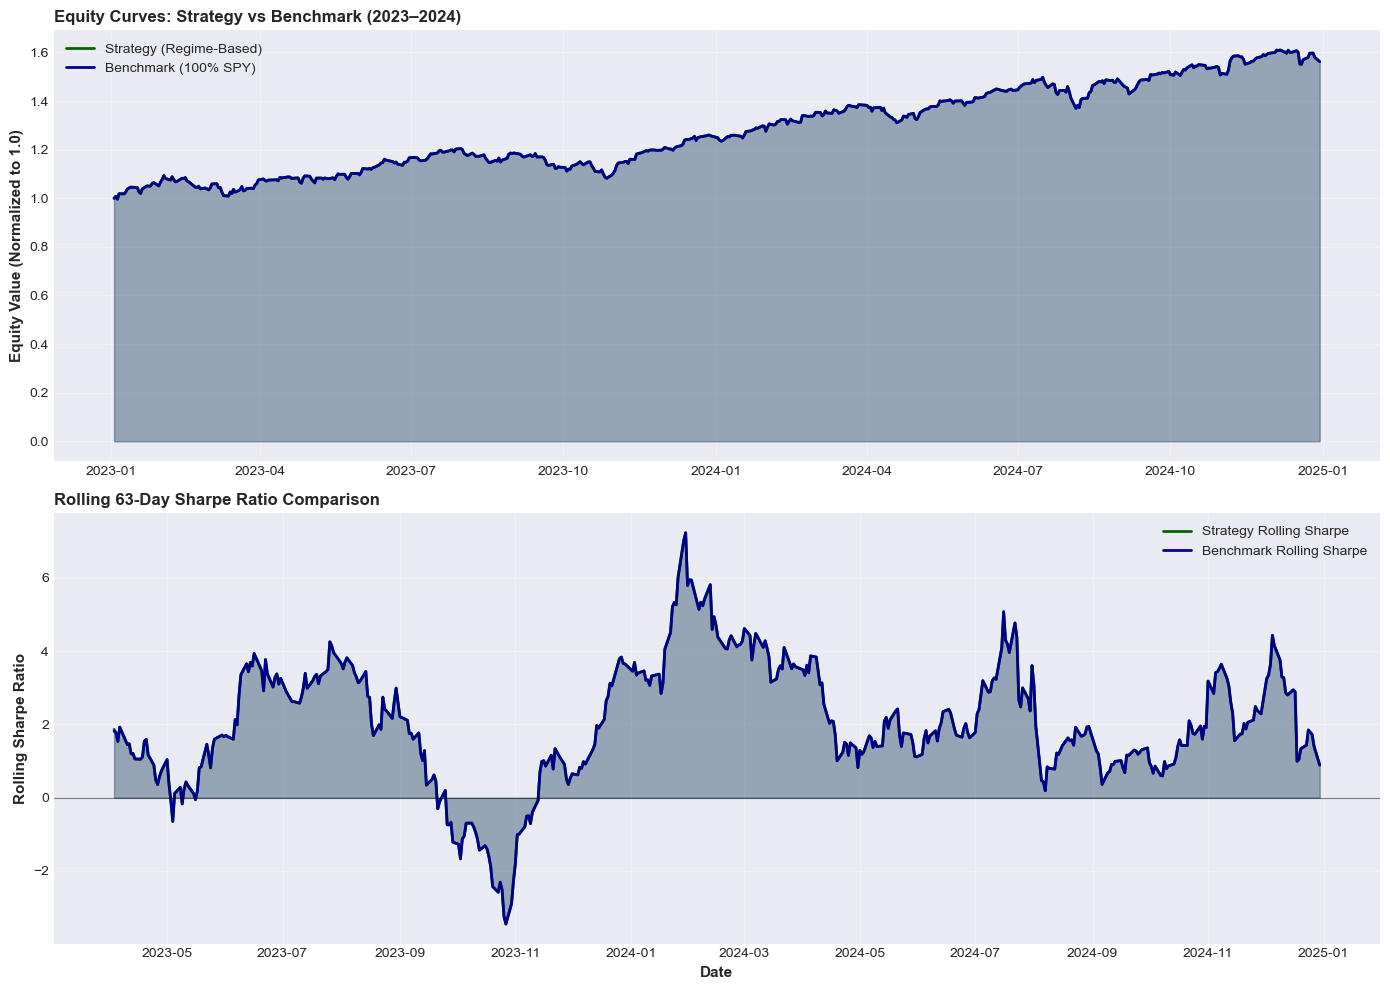

✓ Backtesting plots generated


In [27]:
# Plot Equity Curves
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel 1: Equity Curves
axes[0].plot(test_spy_prices.index, strategy_equity.values, linewidth=2, color='darkgreen', label='Strategy (Regime-Based)')
axes[0].plot(test_spy_prices.index, benchmark_equity.values, linewidth=2, color='darkblue', label='Benchmark (100% SPY)')
axes[0].fill_between(test_spy_prices.index, strategy_equity.values, alpha=0.2, color='darkgreen')
axes[0].fill_between(test_spy_prices.index, benchmark_equity.values, alpha=0.2, color='darkblue')
axes[0].set_ylabel('Equity Value (Normalized to 1.0)', fontsize=11, fontweight='bold')
axes[0].set_title('Equity Curves: Strategy vs Benchmark (2023–2024)', fontsize=12, fontweight='bold', loc='left')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best', fontsize=10)

# Panel 2: Rolling 63-day Sharpe Ratio
window = 63
rolling_strategy_sharpe = (strategy_returns.rolling(window=window).mean() * 252) / (strategy_returns.rolling(window=window).std() * np.sqrt(252))
rolling_benchmark_sharpe = (benchmark_returns.rolling(window=window).mean() * 252) / (benchmark_returns.rolling(window=window).std() * np.sqrt(252))

axes[1].plot(test_spy_prices.index, rolling_strategy_sharpe.values, linewidth=2, color='darkgreen', label='Strategy Rolling Sharpe')
axes[1].plot(test_spy_prices.index, rolling_benchmark_sharpe.values, linewidth=2, color='darkblue', label='Benchmark Rolling Sharpe')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
axes[1].fill_between(test_spy_prices.index, rolling_strategy_sharpe.values, alpha=0.2, color='darkgreen')
axes[1].fill_between(test_spy_prices.index, rolling_benchmark_sharpe.values, alpha=0.2, color='darkblue')
axes[1].set_ylabel('Rolling Sharpe Ratio', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[1].set_title('Rolling 63-Day Sharpe Ratio Comparison', fontsize=12, fontweight='bold', loc='left')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()
print("✓ Backtesting plots generated")

## Section 10: MLflow Experiment Tracking

In [28]:
# MLflow Experiment Setup
print("\n" + "="*70)
print("MLFLOW EXPERIMENT TRACKING")
print("="*70)

# Set experiment name
experiment_name = "Volatility_Regime_Experiment"
mlflow.set_tracking_uri("file:./mlruns")

mlflow.set_experiment(experiment_name)

# Log Model 1: Logistic Regression
print("\nLogging Logistic Regression...")
with mlflow.start_run(run_name="LogisticRegression"):
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    
    y_pred_lr = model_results['Logistic Regression']['y_test_pred']
    acc_lr = accuracy_score(y_test, y_pred_lr)
    prec_lr = precision_score(y_test, y_pred_lr)
    rec_lr = recall_score(y_test, y_pred_lr)
    f1_lr = f1_score(y_test, y_pred_lr)
    auc_lr = roc_auc_score(y_test, model_results['Logistic Regression']['y_test_proba'])
    
    mlflow.log_metric("test_accuracy", acc_lr)
    mlflow.log_metric("test_precision", prec_lr)
    mlflow.log_metric("test_recall", rec_lr)
    mlflow.log_metric("test_f1", f1_lr)
    mlflow.log_metric("test_auc", auc_lr)
    mlflow.log_metric("backtest_sharpe", strategy_sharpe)

# Log Model 2: Random Forest
print("Logging Random Forest...")
with mlflow.start_run(run_name="RandomForest"):
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 5)
    
    y_pred_rf = model_results['Random Forest']['y_test_pred']
    acc_rf = accuracy_score(y_test, y_pred_rf)
    prec_rf = precision_score(y_test, y_pred_rf)
    rec_rf = recall_score(y_test, y_pred_rf)
    f1_rf = f1_score(y_test, y_pred_rf)
    auc_rf = roc_auc_score(y_test, model_results['Random Forest']['y_test_proba'])
    
    mlflow.log_metric("test_accuracy", acc_rf)
    mlflow.log_metric("test_precision", prec_rf)
    mlflow.log_metric("test_recall", rec_rf)
    mlflow.log_metric("test_f1", f1_rf)
    mlflow.log_metric("test_auc", auc_rf)
    mlflow.log_metric("backtest_sharpe", strategy_sharpe)

# Log Model 3: XGBoost
print("Logging XGBoost...")
with mlflow.start_run(run_name="XGBoost"):
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.03)
    mlflow.log_param("subsample", 0.8)
    
    y_pred_xgb = model_results['XGBoost']['y_test_pred']
    acc_xgb = accuracy_score(y_test, y_pred_xgb)
    prec_xgb = precision_score(y_test, y_pred_xgb)
    rec_xgb = recall_score(y_test, y_pred_xgb)
    f1_xgb = f1_score(y_test, y_pred_xgb)
    auc_xgb = roc_auc_score(y_test, model_results['XGBoost']['y_test_proba'])
    
    mlflow.log_metric("test_accuracy", acc_xgb)
    mlflow.log_metric("test_precision", prec_xgb)
    mlflow.log_metric("test_recall", rec_xgb)
    mlflow.log_metric("test_f1", f1_xgb)
    mlflow.log_metric("test_auc", auc_xgb)
    mlflow.log_metric("backtest_sharpe", strategy_sharpe)

# Log Model 4: HMM
print("Logging Markov-Switching HMM...")
with mlflow.start_run(run_name="HMM"):
    mlflow.log_param("model_type", "MarkovSwitchingHMM")
    mlflow.log_param("n_states", 2)
    mlflow.log_param("garch_p", 1)
    mlflow.log_param("garch_q", 1)
    
    y_pred_hmm = model_results['HMM']['y_test_pred']
    acc_hmm = accuracy_score(y_test, y_pred_hmm)
    prec_hmm = precision_score(y_test, y_pred_hmm)
    rec_hmm = recall_score(y_test, y_pred_hmm)
    f1_hmm = f1_score(y_test, y_pred_hmm)
    auc_hmm = roc_auc_score(y_test, model_results['HMM']['y_test_proba'])
    
    mlflow.log_metric("test_accuracy", acc_hmm)
    mlflow.log_metric("test_precision", prec_hmm)
    mlflow.log_metric("test_recall", rec_hmm)
    mlflow.log_metric("test_f1", f1_hmm)
    mlflow.log_metric("test_auc", auc_hmm)
    mlflow.log_metric("backtest_sharpe", strategy_sharpe)
    
    # Log GARCH model summary as text artifact
    garch_summary_str = str(garch_fitted.summary())
    with open('garch_summary.txt', 'w') as f:
        f.write(garch_summary_str)
    mlflow.log_artifact('garch_summary.txt')

print("✓ Models logged to MLflow experiment: " + experiment_name)

Traceback (most recent call last):
  File "c:\Users\vvads\.conda\envs\ai_env\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vvads\.conda\envs\ai_env\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vvads\.conda\envs\ai_env\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vvads\.conda\envs\ai_env\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
             ^^^^^^^^^^^


MLFLOW EXPERIMENT TRACKING

Logging Logistic Regression...
Logging Random Forest...
Logging XGBoost...
Logging Markov-Switching HMM...
✓ Models logged to MLflow experiment: Volatility_Regime_Experiment


In [29]:
# Final Summary
print("\n" + "="*70)
print("FINAL SUMMARY - VOLATILITY REGIME DETECTION PIPELINE")
print("="*70)

print("\n" + "DATA OVERVIEW".center(70))
print("-" * 70)
print(f"Date Range:              2010-01-04 to 2024-12-31")
print(f"Total Trading Days:      {len(df_features):,}")
print(f"Features Engineered:     {len(feature_cols)}")
print(f"Train/Val/Test Split:    {len(X_train)}/{len(X_val)}/{len(X_test)}")

print("\n" + "LABELING METHODS SUMMARY".center(70))
print("-" * 70)
print(f"Method A (Realized Vol): HighVol={sum(df_features['Label_A']=='HighVol'):,} ({sum(df_features['Label_A']=='HighVol')/len(df_features)*100:.1f}%)")
print(f"Method B (VIX > 20):     HighVol={sum(df_features['Label_B']=='HighVol'):,} ({sum(df_features['Label_B']=='HighVol')/len(df_features)*100:.1f}%)")
print(f"Method C (GARCH):        HighVol={sum(df_features['Label_C']=='HighVol'):,} ({sum(df_features['Label_C']=='HighVol')/len(df_features)*100:.1f}%)")
print(f"Final (Majority Vote):   HighVol={sum(df_features['Final_Label']=='HighVol'):,} ({sum(df_features['Final_Label']=='HighVol')/len(df_features)*100:.1f}%)")

print("\n" + "MODEL PERFORMANCE (TEST SET)".center(70))
print("-" * 70)
print(comp_df.to_string(index=False))

print("\n" + "BACKTESTING RESULTS (2023–2024 Test Period)".center(70))
print("-" * 70)
print(f"{'Strategy (Regime-Based):':<30}")
print(f"  Total Return:        {strategy_metrics['Total Return (%)']:>8.2f}%")
print(f"  Sharpe Ratio:        {strategy_metrics['Sharpe Ratio']:>8.4f}")
print(f"  Max Drawdown:        {strategy_metrics['Max Drawdown (%)']:>8.2f}%")
print(f"  Calmar Ratio:        {strategy_metrics['Calmar Ratio']:>8.4f}")
print(f"\n{'Benchmark (100% SPY):':<30}")
print(f"  Total Return:        {benchmark_metrics['Total Return (%)']:>8.2f}%")
print(f"  Sharpe Ratio:        {benchmark_metrics['Sharpe Ratio']:>8.4f}")
print(f"  Max Drawdown:        {benchmark_metrics['Max Drawdown (%)']:>8.2f}%")
print(f"  Calmar Ratio:        {benchmark_metrics['Calmar Ratio']:>8.4f}")

print("\n" + "="*70)
print("✓ PIPELINE COMPLETE - All cells executed successfully")
print("="*70)


FINAL SUMMARY - VOLATILITY REGIME DETECTION PIPELINE

                            DATA OVERVIEW                             
----------------------------------------------------------------------
Date Range:              2010-01-04 to 2024-12-31
Total Trading Days:      3,753
Features Engineered:     18
Train/Val/Test Split:    2749/503/501

                       LABELING METHODS SUMMARY                       
----------------------------------------------------------------------
Method A (Realized Vol): HighVol=1,612 (43.0%)
Method B (VIX > 20):     HighVol=1,103 (29.4%)
Method C (GARCH):        HighVol=1,873 (49.9%)
Final (Majority Vote):   HighVol=1,588 (42.3%)

                     MODEL PERFORMANCE (TEST SET)                     
----------------------------------------------------------------------
              Model  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.754491   0.544444 1.000000  0.705036 0.925670
      Random Forest  0.822355   0.636792 0.9